In [1]:
import pandas as pd

# 1. Download real NYC Uber/Lyft trip data (January 2024 Parquet file)
url = "https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2024-01.parquet"

print("Downloading real Uber/Lyft data... (takes ~15 seconds)")
# Read a sample of 50,000 real trips to keep Colab fast
df_raw = pd.read_parquet(url)
df_real = df_raw.sample(n=50000, random_state=42).copy()

# 2. Map Provider License Numbers to Company Names
license_map = {"HV0003": "Uber", "HV0005": "Lyft"}
df_real["company"] = df_real["hvfhs_license_num"].map(
    license_map
).fillna("Other Rideshare")

# 3. Calculate Real Driver Wait Time (in minutes)
# Difference between when rider requested and when driver arrived
df_real["request_datetime"] = pd.to_datetime(df_real["request_datetime"])
df_real["on_scene_datetime"] = pd.to_datetime(df_real["on_scene_datetime"])

df_real["driver_wait_time_min"] = (
    df_real["on_scene_datetime"] - df_real["request_datetime"]
).dt.total_seconds() / 60.0

# 4. Clean and filter out outliers or missing values
df_real = df_real[
    (df_real["driver_wait_time_min"] > 0)
    & (df_real["driver_wait_time_min"] < 30)
]

print("Real Dataset Loaded Successfully!\n")
print(f"Total Real Trips Loaded: {len(df_real):,}")
print("\n--- First 5 Rows of Real Uber/Lyft Data ---")
df_real[
    [
        "company",
        "request_datetime",
        "PULocationID",
        "base_passenger_fare",
        "driver_pay",
        "driver_wait_time_min",
    ]
].head(5)

Real Dataset Loaded Successfully!

Total Real Trips Loaded: 36,390

--- First 5 Rows of Real Uber/Lyft Data ---


,company,request_datetime,PULocationID,base_passenger_fare,driver_pay,driver_wait_time_min
15895061,Uber,2024-01-26 07:58:05,85,27.49,24.88,8.200000
11113736,Uber,2024-01-19 02:12:56,220,15.14,10.19,3.516667
12716273,Uber,2024-01-21 01:39:37,164,24.57,23.00,4.050000
12099486,Uber,2024-01-20 12:56:18,161,18.96,12.47,2.166667
730768,Uber,2024-01-02 08:22:37,77,16.08,10.64,17.866667


=== REAL MARKETPLACE METRICS (NYC Uber/Lyft) ===
Average Rider Wait Time (ETA): 3.15 minutes
Average Base Fare Paid by Rider: $24.04
Average Driver Pay Earned: $18.25
Platform Take-Rate: 24.1%



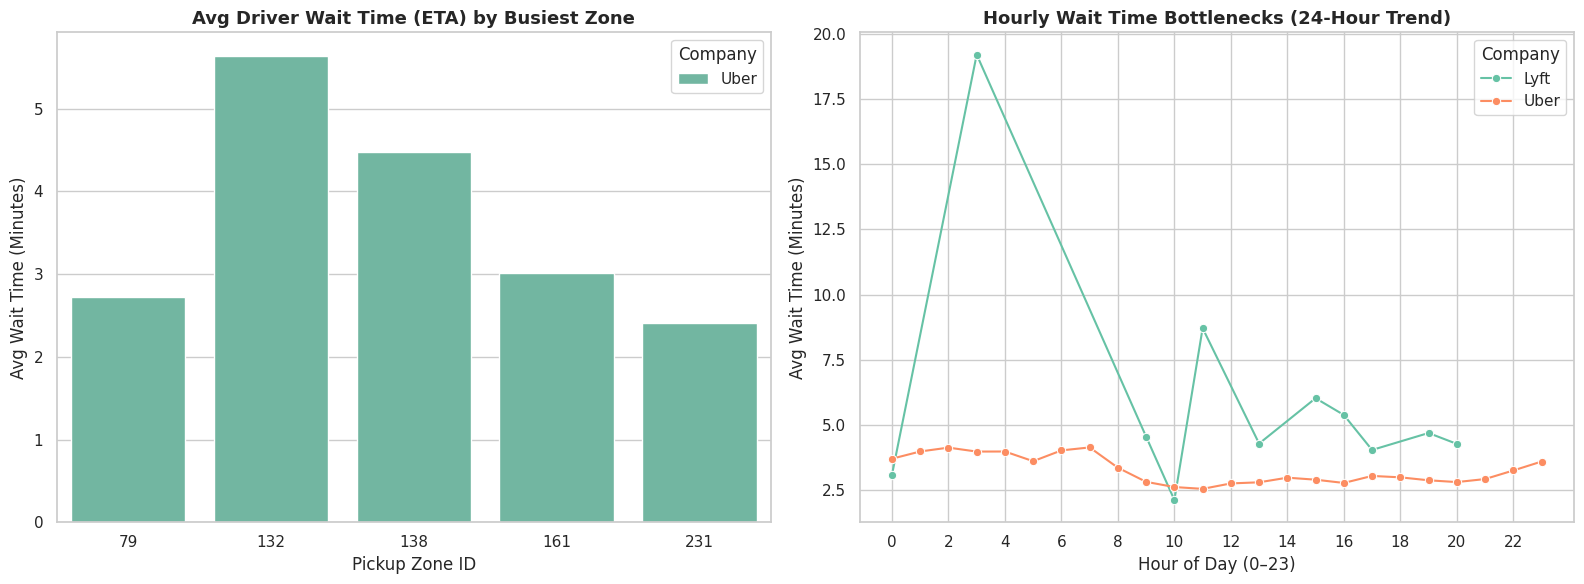

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Core Real-World Metrics
avg_wait_time = df_real["driver_wait_time_min"].mean()
avg_fare = df_real["base_passenger_fare"].mean()
avg_driver_pay = df_real["driver_pay"].mean()
take_rate = ((avg_fare - avg_driver_pay) / avg_fare) * 100

print("=== REAL MARKETPLACE METRICS (NYC Uber/Lyft) ===")
print(f"Average Rider Wait Time (ETA): {avg_wait_time:.2f} minutes")
print(f"Average Base Fare Paid by Rider: ${avg_fare:.2f}")
print(f"Average Driver Pay Earned: ${avg_driver_pay:.2f}")
print(f"Platform Take-Rate: {take_rate:.1f}%\n")

# 2. Data Preparation for Visualizations
df_real["hour"] = df_real["request_datetime"].dt.hour

# Top 5 Busiest Pickup Zones
top_zones = df_real["PULocationID"].value_counts().head(5).index
df_top_zones = df_real[df_real["PULocationID"].isin(top_zones)]

zone_wait_times = (
    df_top_zones.groupby(["PULocationID", "company"])[
        "driver_wait_time_min"
    ]
    .mean()
    .reset_index()
)

# Hourly Wait Times Across the Day
hourly_wait_times = (
    df_real.groupby(["hour", "company"])["driver_wait_time_min"]
    .mean()
    .reset_index()
)

# 3. Create 2 Side-by-Side Visualizations
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CHART 1: Average Wait Times across Busiest Pickup Zones
sns.barplot(
    data=zone_wait_times,
    x="PULocationID",
    y="driver_wait_time_min",
    hue="company",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title(
    "Avg Driver Wait Time (ETA) by Busiest Zone",
    fontsize=13,
    fontweight="bold",
)
axes[0].set_xlabel("Pickup Zone ID")
axes[0].set_ylabel("Avg Wait Time (Minutes)")
axes[0].legend(title="Company")

# CHART 2: Hourly Wait Time Bottlenecks Throughout the Day
sns.lineplot(
    data=hourly_wait_times,
    x="hour",
    y="driver_wait_time_min",
    hue="company",
    marker="o",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title(
    "Hourly Wait Time Bottlenecks (24-Hour Trend)",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_xlabel("Hour of Day (0–23)")
axes[1].set_ylabel("Avg Wait Time (Minutes)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(title="Company")

plt.tight_layout()
plt.show()

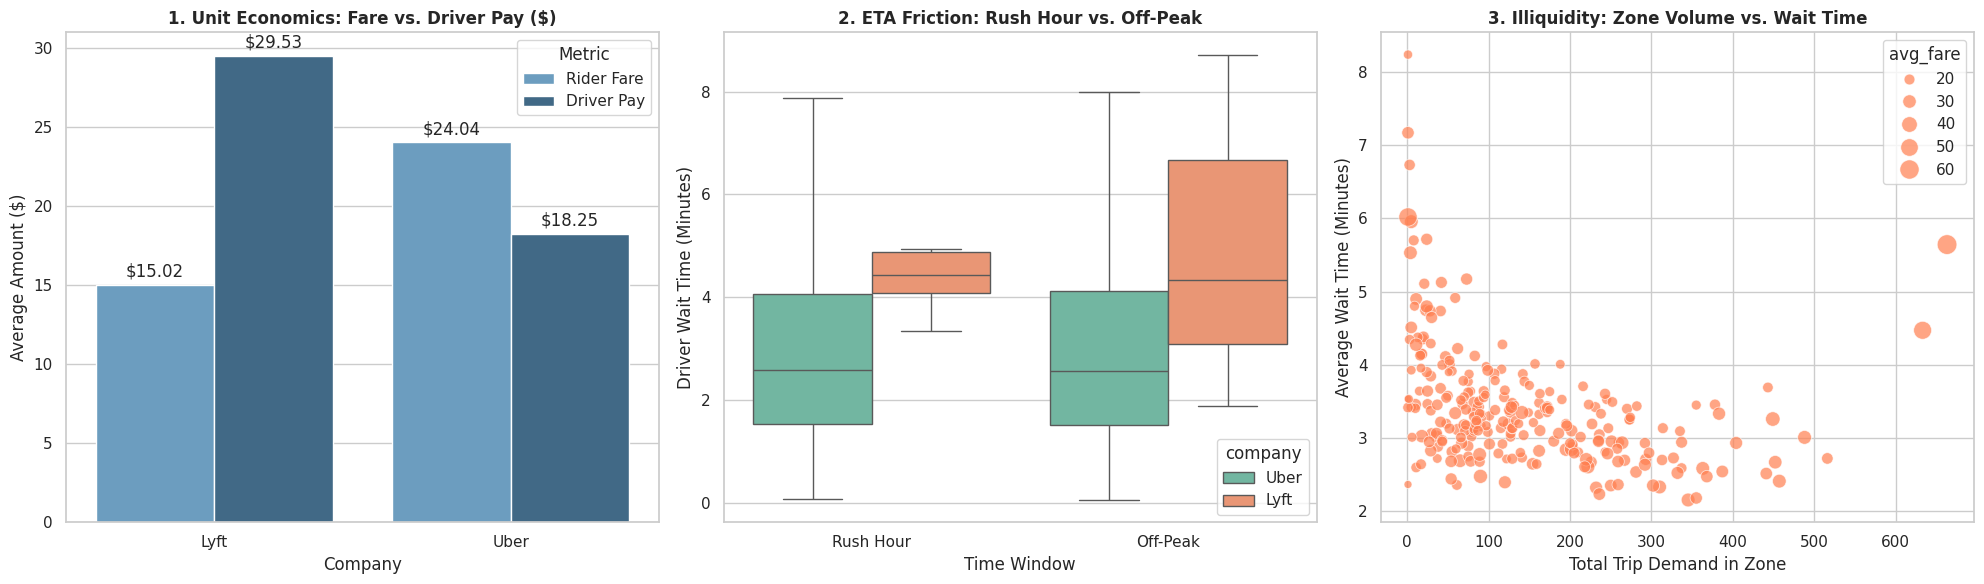

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Feature Engineering for Advanced Analytics
# Define Rush Hours (7-9 AM and 4-7 PM)
df_real["is_rush_hour"] = df_real["hour"].isin([7, 8, 9, 16, 17, 18, 19])
df_real["period_type"] = df_real["is_rush_hour"].map(
    {True: "Rush Hour", False: "Off-Peak"}
)

# Zone Volume vs Wait Time Data
zone_stats = (
    df_real.groupby("PULocationID")
    .agg(
        total_trips=("request_datetime", "count"),
        avg_wait_time=("driver_wait_time_min", "mean"),
        avg_fare=("base_passenger_fare", "mean"),
    )
    .reset_index()
)

# 2. Setup 3-Subplot Figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style="whitegrid")

# CHART 1: Rider Fare vs. Driver Payout (Unit Economics)
fare_pay_df = (
    df_real.groupby("company")[["base_passenger_fare", "driver_pay"]]
    .mean()
    .reset_index()
)
fare_pay_melted = pd.melt(
    fare_pay_df,
    id_vars=["company"],
    value_vars=["base_passenger_fare", "driver_pay"],
    var_name="Metric",
    value_name="Amount ($)",
)
fare_pay_melted["Metric"] = fare_pay_melted["Metric"].map(
    {"base_passenger_fare": "Rider Fare", "driver_pay": "Driver Pay"}
)

sns.barplot(
    data=fare_pay_melted,
    x="company",
    y="Amount ($)",
    hue="Metric",
    palette="Blues_d",
    ax=axes[0],
)
axes[0].set_title(
    "1. Unit Economics: Fare vs. Driver Pay ($)", fontsize=12, fontweight="bold"
)
axes[0].set_ylabel("Average Amount ($)")
axes[0].set_xlabel("Company")

for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(
            f"${p.get_height():.2f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
        )

# CHART 2: Wait Time Reliability (Rush Hour vs. Off-Peak Outliers)
sns.boxplot(
    data=df_real,
    x="period_type",
    y="driver_wait_time_min",
    hue="company",
    palette="Set2",
    showfliers=False,  # Hide extreme statistical outliers for cleaner view
    ax=axes[1],
)
axes[1].set_title(
    "2. ETA Friction: Rush Hour vs. Off-Peak", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Time Window")
axes[1].set_ylabel("Driver Wait Time (Minutes)")

# CHART 3: Zone Demand Volume vs. Wait Time Bottleneck
sns.scatterplot(
    data=zone_stats,
    x="total_trips",
    y="avg_wait_time",
    size="avg_fare",
    sizes=(30, 200),
    alpha=0.7,
    color="coral",
    ax=axes[2],
)
axes[2].set_title(
    "3. Illiquidity: Zone Volume vs. Wait Time", fontsize=12, fontweight="bold"
)
axes[2].set_xlabel("Total Trip Demand in Zone")
axes[2].set_ylabel("Average Wait Time (Minutes)")

plt.tight_layout()
plt.show()